In [79]:

## Importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer
import matplotlib.ticker as mtick
import matplotlib.ticker as ticker

In [80]:
## Loading Data
fce = pd.read_csv("../datasets/farm_cat_eco.csv")

In [81]:
## Inspect data
fce.head()


,year,territory,lambs,rams,ewes,lamb_sheep_shorn,sheep_flock,sheep_purchased,cats_occurrence_total,cats_forest,...,eco_sector_authorities_stakeholders,eco_sector_environment,eco_sector_health,eco_type_control,eco_type_control_education,eco_type_control_medical_care,eco_type_control_prevention,eco_type_damage_loss,eco_type_eradication,eco_type_prevention
0,2002,All Australia,10658.0,662.0,26531.0,51883.0,47861.0,3300.0,197.0,77.0,...,825276.359414,0.0,0.0,825276.359414,0.0,0.0,0.0,0.0,0.0,0.0
1,2002,New South Wales,2624.0,131.0,5996.0,11360.0,10544.0,770.0,104.0,46.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2002,Northern Territory,0.0,0.0,0.0,0.0,0.0,0.0,34.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2002,Queensland,1421.0,103.0,5020.0,11123.0,9707.0,584.0,24.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2002,South Australia,2148.0,137.0,5372.0,8857.0,8938.0,692.0,18.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
fce.isna().sum()

year                                     0
territory                                0
lambs                                   25
rams                                    25
ewes                                    25
lamb_sheep_shorn                        11
sheep_flock                             11
sheep_purchased                         11
cats_occurrence_total                   32
cats_forest                             32
eco_cost_total                         146
eco_cost_cat_only                      146
eco_cost_cat_plus_other                146
eco_sector_agriculture                 146
eco_sector_authorities_stakeholders    146
eco_sector_environment                 146
eco_sector_health                      146
eco_type_control                       146
eco_type_control_education             146
eco_type_control_medical_care          146
eco_type_control_prevention            146
eco_type_damage_loss                   146
eco_type_eradication                   146
eco_type_pr

In [83]:
# Clean column names
fce.columns = fce.columns.str.strip()

# Keep only Australia
fce = fce[fce["territory"] == "All Australia"].copy()

fce = fce[[
    'year',
    'cats_occurrence_total',
    'sheep_flock',
    'territory',
    'eco_cost_total',
    'eco_type_control',
    'eco_type_control_education',
    'eco_type_control_medical_care',
    'eco_type_control_prevention',
    'eco_type_damage_loss',
    'eco_type_eradication',
    'eco_type_prevention'
]]

In [84]:
fce.isna().sum()

year                             0
cats_occurrence_total            0
sheep_flock                      0
territory                        0
eco_cost_total                   8
eco_type_control                 8
eco_type_control_education       8
eco_type_control_medical_care    8
eco_type_control_prevention      8
eco_type_damage_loss             8
eco_type_eradication             8
eco_type_prevention              8
dtype: int64

In [85]:
fce = fce.dropna(subset=[
    'cats_occurrence_total',
    'sheep_flock',
    'eco_type_damage_loss'
])

In [86]:
## Adding "all Australia"
aus = fce[fce["territory"] == "All Australia"]

# Type of cost categorization




In [87]:
## Type of costs diviation 
cost_types = [
    "eco_type_control",
    "eco_type_damage_loss",
    "eco_type_eradication",
    "eco_type_prevention"
]

cost_structure = aus[cost_types].sum()
cost_structure = cost_structure.round(0).astype(int)
cost_structure

eco_type_control         2282268
eco_type_damage_loss     7940169
eco_type_eradication    33836150
eco_type_prevention      1213341
dtype: int64

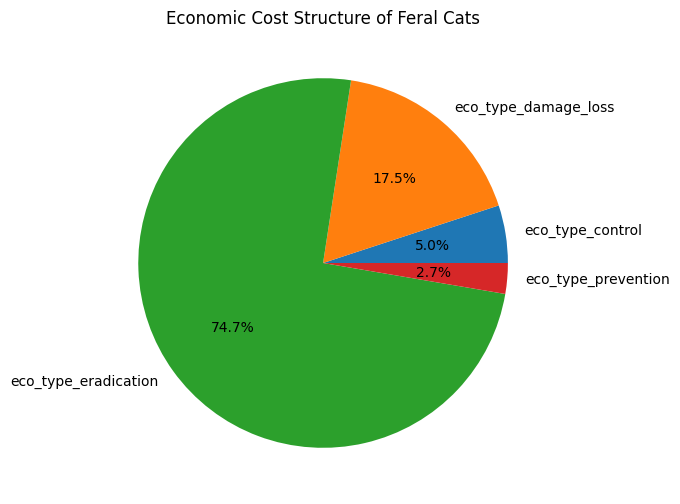

In [88]:
## Visualizing

cost_structure.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Economic Cost Structure of Feral Cats")
plt.ylabel("")
plt.show()

# Control Vs. Damage costs comparison


In [89]:
## Control Costs categorization
control_cost = (
    cost_structure["eco_type_control"]
    + cost_structure["eco_type_eradication"]
    + cost_structure["eco_type_prevention"]
)

In [90]:
## Damage Cost Categorization
damage_cost = cost_structure["eco_type_damage_loss"]

In [91]:
comparison = pd.Series({
    "Control spending": control_cost,
    "Damage losses": damage_cost
})

comparison

Control spending    37331759
Damage losses        7940169
dtype: int64

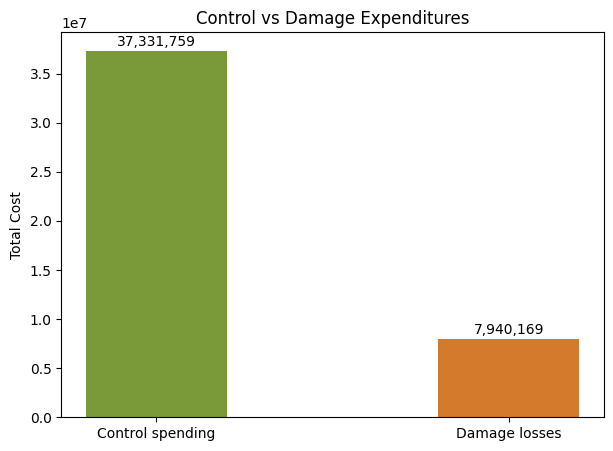

In [92]:
## Visualization of the control VS. damage stats
labels = comparison.index
values = comparison.values

x = np.arange(len(labels))

plt.figure(figsize=(7,5))

plt.bar(x, values, width=0.4, color=["#7a9a3a", "#d47a2c"])

plt.xticks(x, labels)
plt.ylabel("Total Cost")
plt.title("Control vs Damage Expenditures")

for i, v in enumerate(values):
    plt.text(i, v + 500000, f"{v:,.0f}", ha="center")

plt.show()

## Temporal Dynamics of Economic Cost

First, we aggrigate overall economics cost by year

In [93]:
## Costs by year depedning on the type of loss
cost_by_year = aus.groupby("year")[cost_types].sum()

cost_by_year = cost_by_year.applymap(lambda x: f"{x:,.0f}")
cost_by_year

C:\Users\User\AppData\Local\Temp\ipykernel_18484\964814017.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cost_by_year = cost_by_year.applymap(lambda x: f"{x:,.0f}")


,eco_type_control,eco_type_damage_loss,eco_type_eradication,eco_type_prevention
year,,,,
2002,"825,276",0,0,0
2004,"1,180,696",0,0,0
2006,"11,185",0,"3,139,774",0
2009,0,0,0,0
2010,"11,162",0,"29,227",0
2011,0,0,"111,794",0
2012,"126,802",0,"1,102",0
2013,"29,462",0,"28,708,160",0
2014,"2,023",0,0,"1,213,341"


### Cost dynamics by category

To compare how different cost categories evolve over time, we visualize each category in a separate subplot.  
All plots share the same scale to allow a direct comparison of expenditure levels across categories.

,eco_type_control,eco_type_damage_loss,eco_type_eradication,eco_type_prevention
year,,,,
2002,"825,276",0,0,0
2004,"1,180,696",0,0,0
2006,"11,185",0,"3,139,774",0
2009,0,0,0,0
2010,"11,162",0,"29,227",0
2011,0,0,"111,794",0
2012,"126,802",0,"1,102",0
2013,"29,462",0,"28,708,160",0
2014,"2,023",0,0,"1,213,341"


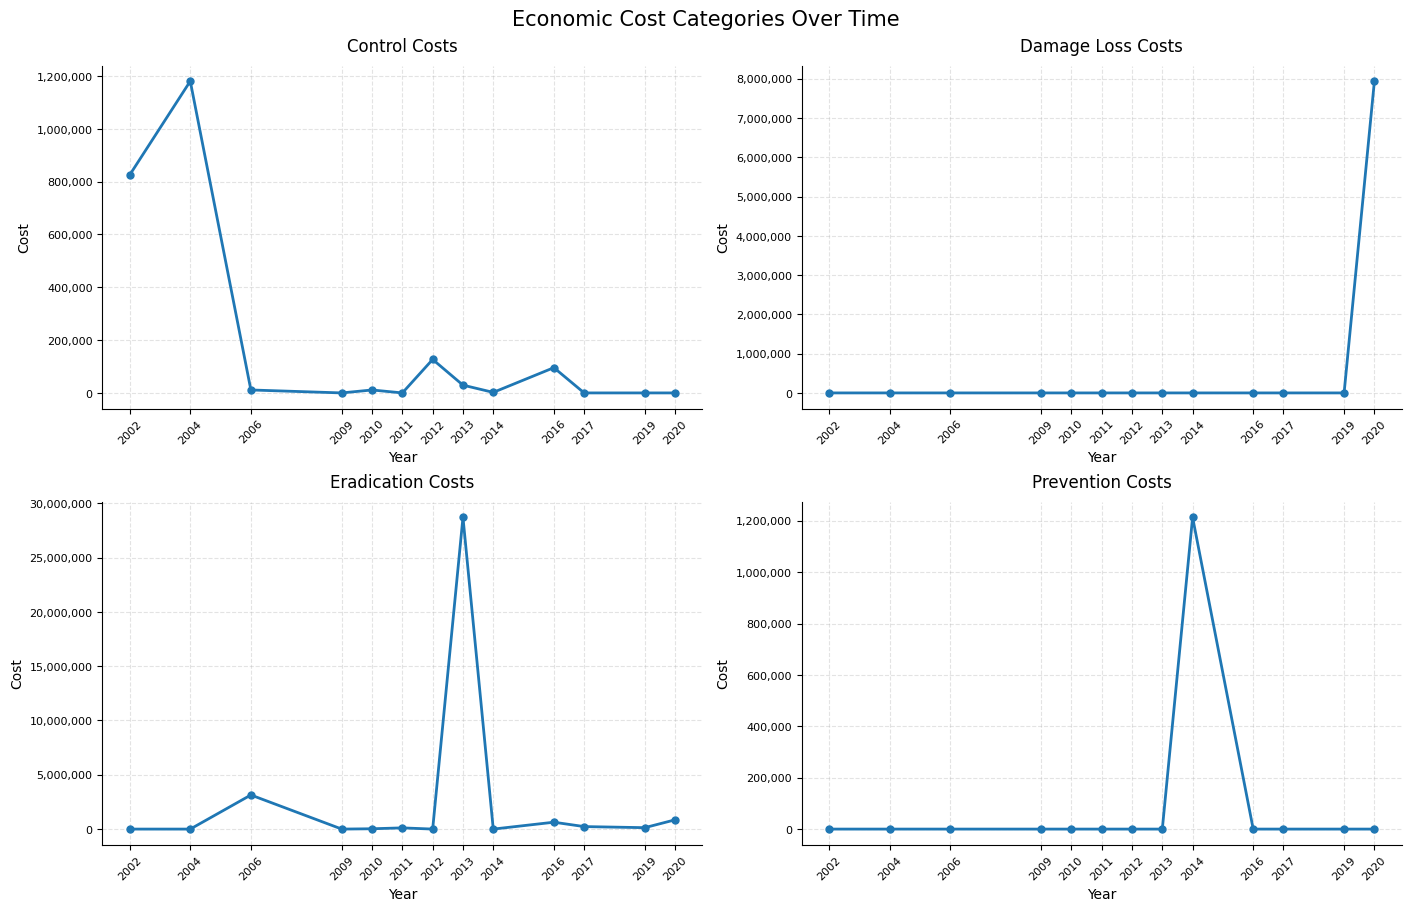

eco_type_control        object
eco_type_damage_loss    object
eco_type_eradication    object
eco_type_prevention     object
dtype: object


In [94]:


# 1) cost columns
cost_types = [
    "eco_type_control",
    "eco_type_damage_loss",
    "eco_type_eradication",
    "eco_type_prevention"
]

nice_names = {
    "eco_type_control": "Control Costs",
    "eco_type_damage_loss": "Damage Loss Costs",
    "eco_type_eradication": "Eradication Costs",
    "eco_type_prevention": "Prevention Costs"
}

# 2) numeric table for plotting
cost_by_year_num = aus.groupby("year")[cost_types].sum().astype(float)

# 3) optional: pretty table just for viewing
cost_by_year_display = cost_by_year_num.apply(lambda col: col.map(lambda x: f"{x:,.0f}"))
display(cost_by_year_display)

# 4) separate plots
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(cost_types):
    ax = axes[i]

    ax.plot(
        cost_by_year_num.index,
        cost_by_year_num[col],
        marker="o",
        linewidth=2,
        markersize=5
    )

    ax.set_title(nice_names[col], fontsize=12, pad=10)
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel("Cost", fontsize=10)

    # only real years on x-axis
    ax.set_xticks(cost_by_year_num.index)
    ax.set_xticklabels(cost_by_year_num.index.astype(int), rotation=45)

    # correct money formatting on y-axis
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    # cleaner look
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle("Economic Cost Categories Over Time", fontsize=15)
plt.show()
print(cost_by_year.dtypes)

### Total economic cost over time

Next, we calculate the total economic cost per year by summing all cost categories.  
This helps us observe how the overall economic impact of feral cats changes across years.

In [95]:
cost_by_year = cost_by_year.replace(',', '', regex=True).astype(float)
total_cost_year = cost_by_year.sum(axis=1)
print(total_cost_year)

year
2002      825276.0
2004     1180696.0
2006     3150959.0
2009           0.0
2010       40389.0
2011      111794.0
2012      127904.0
2013    28737622.0
2014     1215364.0
2016      728926.0
2017      230142.0
2019      130297.0
2020     8792557.0
dtype: float64


### Visualizing total cost dynamics

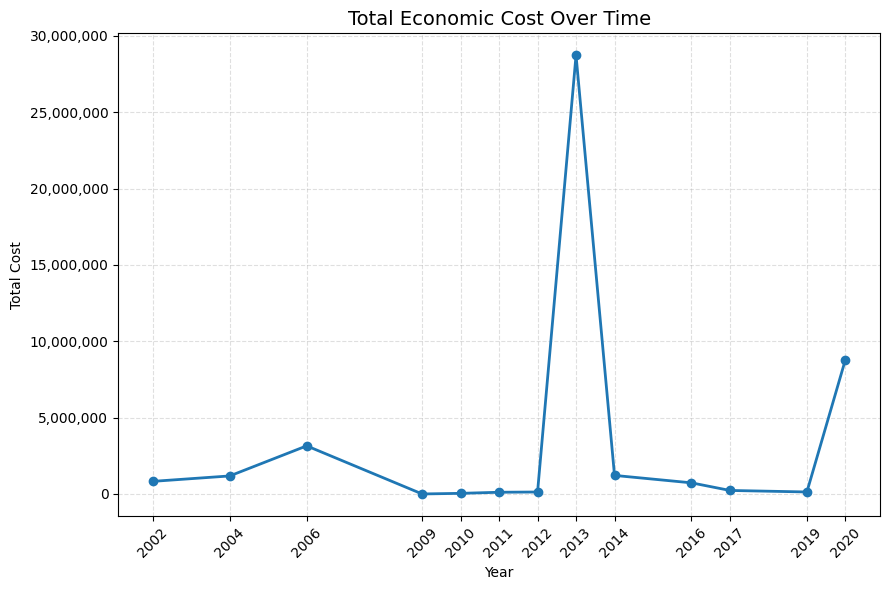

In [96]:
plt.figure(figsize=(9,6))

plt.plot(
    total_cost_year.index,
    total_cost_year.values,
    marker="o",
    linewidth=2
)

plt.title("Total Economic Cost Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total Cost")

plt.xticks(total_cost_year.index, total_cost_year.index.astype(int), rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Violation testing

## Linearity

### Linearity: Cats vs Economic Loss

In this section, we test whether the relationship between feral cat occurrence and total economic loss can be adequately described by a linear model.

Linearity is a key assumption in many statistical models, especially linear regression. It implies that changes in the independent variable (cat occurrence) lead to proportional changes in the dependent variable (economic loss).

To evaluate this, we compare:
- a linear fit, which assumes a constant rate of change,
- a polynomial fit, which allows for curvature in the relationship.

Additionally, we analyze the residuals from the linear model.  
If the relationship is truly linear, residuals should be randomly scattered around zero with no systematic pattern.

Deviations from this pattern may indicate:
- non-linearity,
- missing variables,
- or structural changes in the data.

In [97]:
fce.columns = fce.columns.str.strip()

## convertation to numbers
cols = ['cats_occurrence_total', 'eco_cost_total', 'sheep_flock']

for col in cols:
    fce[col] = pd.to_numeric(fce[col], errors='coerce')

# all Australia
aus = fce[fce['territory'] == 'All Australia'].copy()

aus = aus.sort_values('year').dropna(
    subset=['cats_occurrence_total', 'eco_cost_total']
)

## X и y
X = aus['cats_occurrence_total'].values.reshape(-1, 1)
y = aus['eco_cost_total'].values

##  Linear Regression
lin = LinearRegression().fit(X, y)
y_pred_lin = lin.predict(X)
residuals = y - y_pred_lin

## Polynomial
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

pol = LinearRegression().fit(X_poly, y)
y_pred_poly = pol.predict(X_poly)

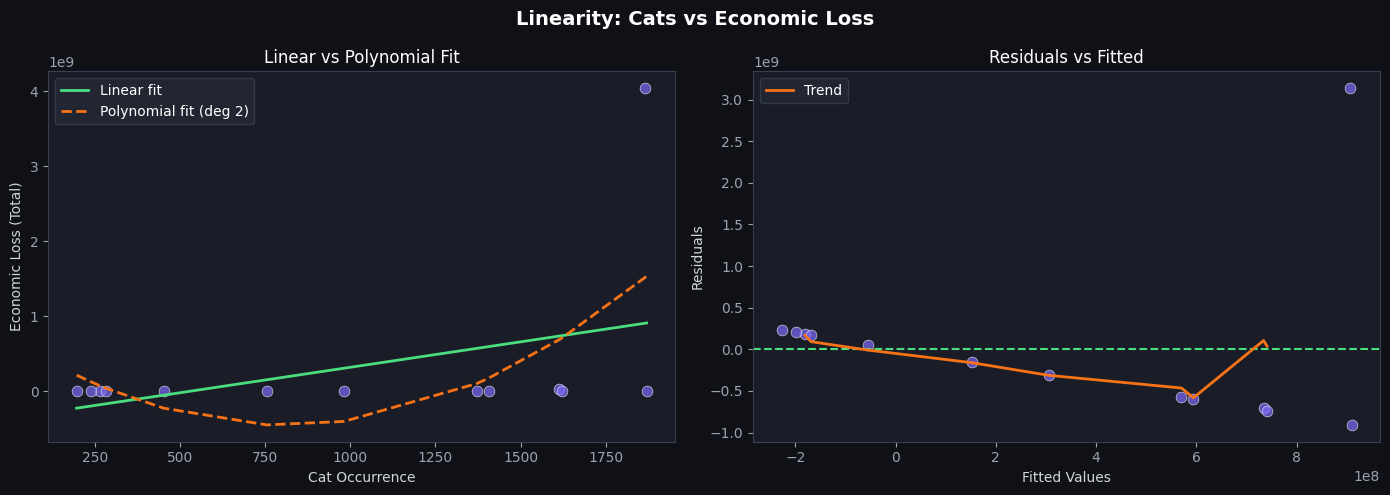

In [98]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Linearity: Cats vs Economic Loss', fontsize=14, color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

## Scatter + fits
ax = axes[0]
ax.scatter(X, y, color=A1, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

sort_idx = X.flatten().argsort()
ax.plot(X[sort_idx], y_pred_lin[sort_idx], color=A2, linewidth=2, label='Linear fit')
ax.plot(X[sort_idx], y_pred_poly[sort_idx], color=A3, linewidth=2,
        linestyle='--', label='Polynomial fit (deg 2)')

ax.set_xlabel('Cat Occurrence')
ax.set_ylabel('Economic Loss (Total)')
ax.set_title('Linear vs Polynomial Fit')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

## Residuals
ax = axes[1]
ax.scatter(y_pred_lin, residuals, color=A1, alpha=0.7, s=60,
           edgecolors='white', linewidth=0.5)

ax.axhline(0, color=A2, linewidth=1.5, linestyle='--')

sort_idx2 = y_pred_lin.argsort()
ax.plot(np.sort(y_pred_lin),
        pd.Series(residuals[sort_idx2]).rolling(5, center=True).mean(),
        color=A3, linewidth=2, label='Trend')

ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.show()

The results suggest that the relationship between cat occurrence and economic loss is not strictly linear.

First, the polynomial  line fits the data better than the straight linear line. This means that economic costs do not increase at a constant rate 

Second, the residual plot shows a visible pattern instead of random noise. In a good linear model, residuals should be scattered randomly around zero. Since this is not the case here, it indicates that the linear model does not fully capture the relationship.

We also observe an outlier, where economic losses are much higher than expected. This point may represent specific events or years with unusually high impact.

Overall, this suggests that:
- the relationship is more complex than a straight line,
- a linear model is too simple,

Moreover, there are years with high cat occurrence but low recorded economic loss, suggesting that the relationship is not immediate or may depend on additional factors such as delayed effects or intervention policies

## R^2 results:

In [99]:
print(f"Linear R²:     {lin.score(X, y):.4f}")
print(f"Polynomial R²: {pol.score(X_poly, y):.4f}")

Linear R²:     0.1595
Polynomial R²: 0.3232


The polynomial model performs better, meaning it captures the relationship more accurately than the linear model.

However, both values are relatively low, suggesting that cat occurrence alone does not fully explain economic losses... but as it was mentioned before we wiil check dependence on other factors.


## Autocorrelation

In this section, we examine whether economic losses are correlated with their own past values over time.


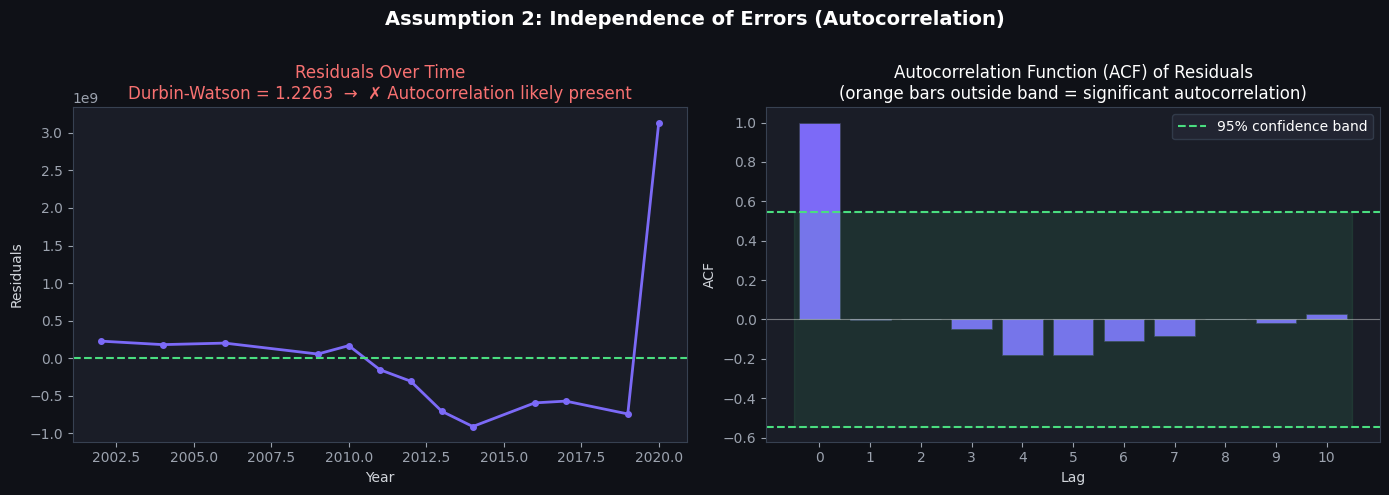

Durbin-Watson: 1.2263
Interpretation: ~2 = no autocorrelation | <1.5 = positive | >2.5 = negative


In [100]:
## making the columns numeric
cols = ['year', 'cats_occurrence_total', 'eco_cost_total']

for col in cols:
    fce[col] = pd.to_numeric(fce[col], errors='coerce')

## taking only All Australia
aus = fce[fce['territory'] == 'All Australia'].copy()

## sort by yearn and drop NaNs
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'eco_cost_total'])

## X и y
X = aus['cats_occurrence_total'].values.reshape(-1, 1)
y = aus['eco_cost_total'].values

## linear regression and residuals 
lin = LinearRegression().fit(X, y)
y_pred = lin.predict(X)
residuals = y - y_pred

## Durbin-Watson statistic
dw = np.sum(np.diff(residuals) ** 2) / np.sum(residuals ** 2)

# ACF function
def acf(x, nlags=10):
    n = len(x)
    xd = x - x.mean()
    var = np.dot(xd, xd) / n
    return [
        np.dot(xd[:n-lag], xd[lag:]) / n / var if lag < n else 0
        for lag in range(nlags + 1)
    ]

lags_range = min(10, len(residuals) - 1)
acf_vals = np.array(acf(residuals, nlags=lags_range))
conf = 1.96 / np.sqrt(len(residuals))

## colors
DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

## plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Assumption 2: Independence of Errors (Autocorrelation)',
             fontsize=14, color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

## residuals over time
ax = axes[0]
ax.plot(aus['year'].values, residuals, color=A1, linewidth=2, marker='o', markersize=4)
ax.axhline(0, color=A2, linewidth=1.5, linestyle='--')

verdict = "✓ No strong autocorrelation" if 1.5 < dw < 2.5 else "✗ Autocorrelation likely present"
v_color = '#4ade80' if 1.5 < dw < 2.5 else '#f87171'

ax.set_title(f'Residuals Over Time\nDurbin-Watson = {dw:.4f}  →  {verdict}')
ax.title.set_color(v_color)
ax.set_xlabel('Year')
ax.set_ylabel('Residuals')

## ACF plot
ax = axes[1]
lags = np.arange(lags_range + 1)
bar_colors = [A3 if abs(v) > conf and i > 0 else A1 for i, v in enumerate(acf_vals)]

ax.bar(lags, acf_vals, color=bar_colors, edgecolor='#374151', linewidth=0.5)
ax.axhline(conf, color=A2, linewidth=1.5, linestyle='--', label='95% confidence band')
ax.axhline(-conf, color=A2, linewidth=1.5, linestyle='--')
ax.fill_between([-0.5, lags_range + 0.5], -conf, conf, alpha=0.1, color=A2)
ax.axhline(0, color='white', linewidth=0.8, alpha=0.4)

ax.set_xticks(lags)
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_title('Autocorrelation Function (ACF) of Residuals\n'
             '(orange bars outside band = significant autocorrelation)')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.show()

print(f"Durbin-Watson: {dw:.4f}")
print("Interpretation: ~2 = no autocorrelation | <1.5 = positive | >2.5 = negative")

### Interpretation of Results

The results suggest that the residuals are not fully independent over time, indicating the presence of autocorrelation.

First, the Durbin–Watson statistic is approximately **1.23**, which is below the benchmark value of 2. This indicates positive autocorrelation, meaning that residuals tend to follow similar patterns from one year to the next.

Second, the residuals plotted over time show a clear structured pattern rather than random fluctuations. We observe periods where residuals remain consistently above or below zero, suggesting persistence in the errors.

Third, the ACF (autocorrelation function) plot shows that some lags exhibit noticeable correlation. Although most values fall within the confidence band, the overall pattern still suggests some degree of time dependence.

Overall, these results imply that:
- the independence assumption of linear regression is likely violated,
- errors are correlated across time,
- and past values of economic loss (or omitted factors) may influence current outcomes.

This suggests that a time-series approach or the inclusion of lagged variables may improve the model.

## Homoscedasticity

In this section, we test the assumption of homoscedasticity, which means that the variance of the errors (residuals) is constant across all levels of the independent variable.



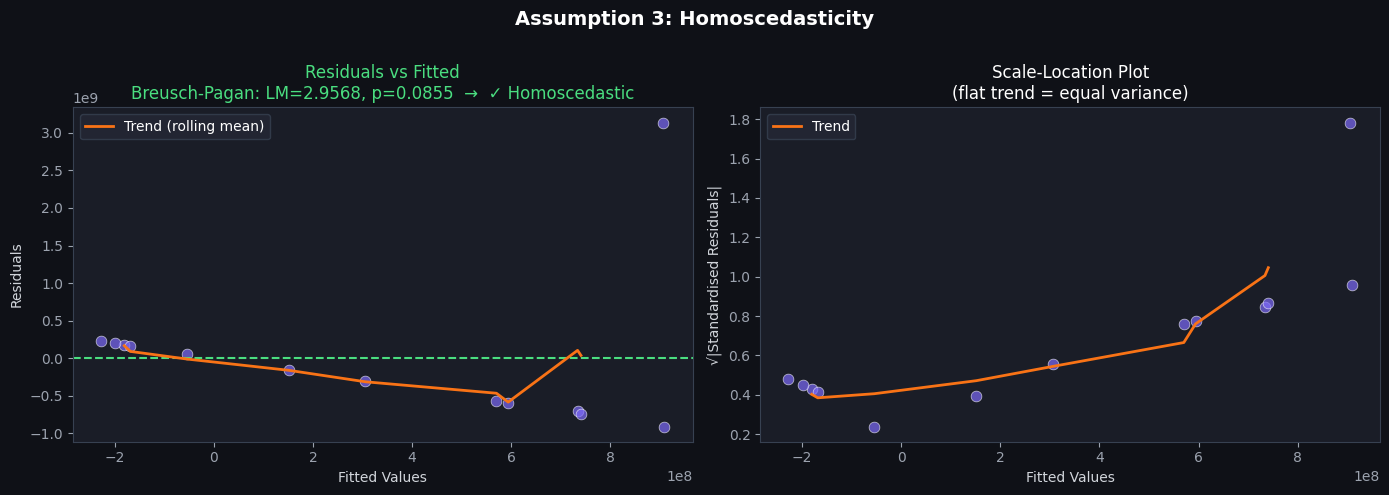

Breusch-Pagan LM: 2.9568, p=0.0855
If p < 0.05: heteroscedasticity present (violation).


In [101]:

fce.columns = fce.columns.str.strip()

cols = ['year', 'cats_occurrence_total', 'eco_cost_total']
for col in cols:
    fce[col] = pd.to_numeric(fce[col], errors='coerce')

aus = fce[fce['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'eco_cost_total'])

X = aus['cats_occurrence_total'].values.reshape(-1, 1)
y = aus['eco_cost_total'].values

lin = LinearRegression().fit(X, y)
y_pred = lin.predict(X)
residuals = y - y_pred

## Breusch-Pagan test (manual version)
resid_sq = residuals ** 2
X_bp = np.column_stack([np.ones(len(X)), X.flatten()])
beta = np.linalg.lstsq(X_bp, resid_sq, rcond=None)[0]
resid_sq_pred = X_bp @ beta

ss_res = np.sum((resid_sq - resid_sq_pred) ** 2)
ss_tot = np.sum((resid_sq - resid_sq.mean()) ** 2)
r2_bp = 1 - ss_res / ss_tot

n = len(y)
bp_lm = n * r2_bp
bp_p = 1 - stats.chi2.cdf(bp_lm, df=1)

DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Assumption 3: Homoscedasticity', fontsize=14,
             color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

## Residuals vs fitted
ax = axes[0]
ax.scatter(y_pred, residuals, color=A1, alpha=0.7, s=60,
           edgecolors='white', linewidth=0.5)
ax.axhline(0, color=A2, linewidth=1.5, linestyle='--')

sort_idx = y_pred.argsort()
ax.plot(np.sort(y_pred),
        pd.Series(residuals[sort_idx]).rolling(5, center=True).mean(),
        color=A3, linewidth=2, label='Trend (rolling mean)')

verdict = "✓ Homoscedastic" if bp_p > 0.05 else "✗ Heteroscedastic"
v_color = '#4ade80' if bp_p > 0.05 else '#f87171'

ax.set_title(f'Residuals vs Fitted\nBreusch-Pagan: LM={bp_lm:.4f}, p={bp_p:.4f}  →  {verdict}')
ax.title.set_color(v_color)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

# Scale-location plot
ax = axes[1]
std_resid = residuals / residuals.std()
ax.scatter(y_pred, np.sqrt(np.abs(std_resid)), color=A1, alpha=0.7,
           s=60, edgecolors='white', linewidth=0.5)
ax.plot(np.sort(y_pred),
        pd.Series(np.sqrt(np.abs(std_resid))[sort_idx]).rolling(5, center=True).mean(),
        color=A3, linewidth=2, label='Trend')

ax.set_xlabel('Fitted Values')
ax.set_ylabel('√|Standardised Residuals|')
ax.set_title('Scale-Location Plot\n(flat trend = equal variance)')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.show()

print(f"Breusch-Pagan LM: {bp_lm:.4f}, p={bp_p:.4f}")
print("If p < 0.05: heteroscedasticity present (violation).")

The results suggest that the assumption of homoscedasticity is not strongly violated, but there are signs of increasing variance at higher levels.

First, the Breusch–Pagan test gives a p-value of **0.0855**, which is above the 0.05 threshold. This means we do not have strong statistical evidence of heteroscedasticity, and the assumption of constant variance is not formally rejected.

However, visual inspection tells a more nuanced story. In the residuals vs fitted plot, residuals appear relatively stable at lower fitted values but become more spread out as fitted values increase. This indicates that the model's errors grow in magnitude for larger predicted economic losses.

The test does not show strong evidence of heteroscedasticity, but the plots suggest that errors become larger at higher values. This means the model works better for small economic losses and less accurately for large ones.

## Normality

In this section, we test whether the residuals of the model are normally distributed.

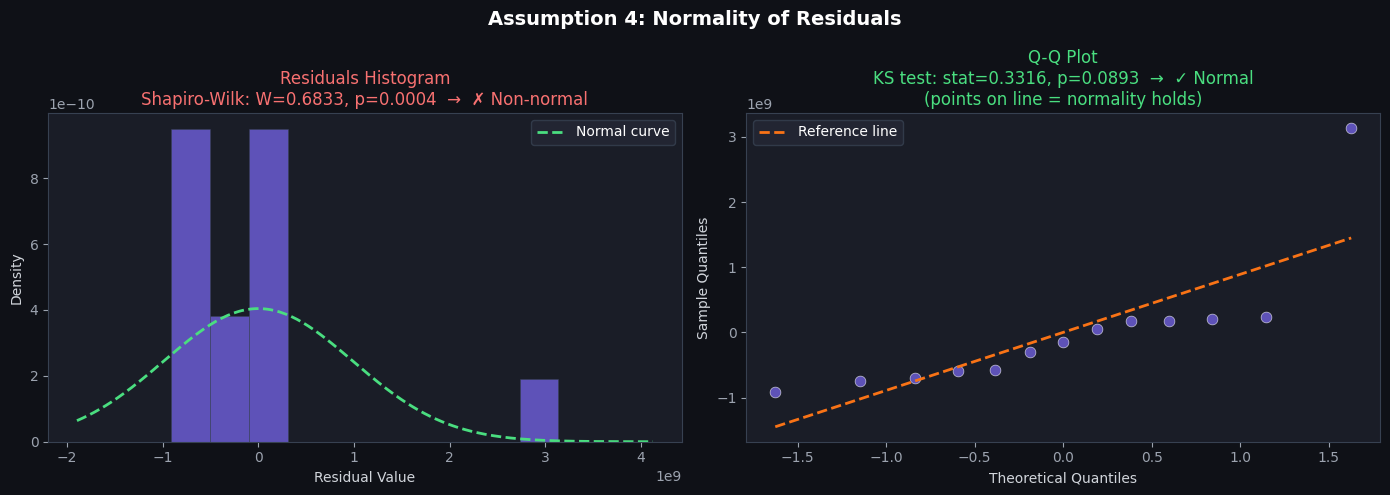

Shapiro-Wilk: W=0.6833, p=0.0004
KS test:      stat=0.3316, p=0.0893
If p < 0.05: residuals are not normally distributed (violation).


In [102]:
fce.columns = fce.columns.str.strip()

cols = ['year', 'cats_occurrence_total', 'eco_cost_total']
for col in cols:
    fce[col] = pd.to_numeric(fce[col], errors='coerce')

aus = fce[fce['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'eco_cost_total'])

X = aus['cats_occurrence_total'].values.reshape(-1, 1)
y = aus['eco_cost_total'].values

lin = LinearRegression().fit(X, y)
y_pred = lin.predict(X)
residuals = y - y_pred

sw_stat, sw_p = stats.shapiro(residuals)
ks_stat, ks_p = stats.kstest(
    residuals,
    'norm',
    args=(residuals.mean(), residuals.std())
)

DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Assumption 4: Normality of Residuals', fontsize=14,
             color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

# Histogram
ax = axes[0]
ax.hist(residuals, bins=10, density=True, color=A1, alpha=0.7,
        edgecolor='#374151', linewidth=0.5)

x_line = np.linspace(
    residuals.min() - residuals.std(),
    residuals.max() + residuals.std(),
    200
)

ax.plot(
    x_line,
    stats.norm.pdf(x_line, residuals.mean(), residuals.std()),
    color=A2, linewidth=2, linestyle='--', label='Normal curve'
)

sw_verdict = "✓ Normal" if sw_p > 0.05 else "✗ Non-normal"
sw_color = '#4ade80' if sw_p > 0.05 else '#f87171'

ax.set_title(f'Residuals Histogram\nShapiro-Wilk: W={sw_stat:.4f}, p={sw_p:.4f}  →  {sw_verdict}')
ax.title.set_color(sw_color)
ax.set_xlabel('Residual Value')
ax.set_ylabel('Density')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

# Q-Q plot
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')

ax.scatter(osm, osr, color=A1, alpha=0.7, s=60,
           edgecolors='white', linewidth=0.5)
ax.plot(osm, slope * np.array(osm) + intercept, color=A3,
        linewidth=2, linestyle='--', label='Reference line')

ks_verdict = "✓ Normal" if ks_p > 0.05 else "✗ Non-normal"
ks_color = '#4ade80' if ks_p > 0.05 else '#f87171'

ax.set_title(
    f'Q-Q Plot\nKS test: stat={ks_stat:.4f}, p={ks_p:.4f}  →  {ks_verdict}\n'
    f'(points on line = normality holds)'
)
ax.title.set_color(ks_color)
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.show()

print(f"Shapiro-Wilk: W={sw_stat:.4f}, p={sw_p:.4f}")
print(f"KS test:      stat={ks_stat:.4f}, p={ks_p:.4f}")
print("If p < 0.05: residuals are not normally distributed (violation).")

The normality assumption is not fully satisfied. The Shapiro–Wilk test indicates non-normality (p < 0.05), likely due to outliers, while the Q–Q plot shows some deviations at the extremes. Overall, residuals are approximately normal but influenced by extreme values.

## Outliers

In this section, we examine whether certain observations (years) have a disproportionate influence on the regression results.


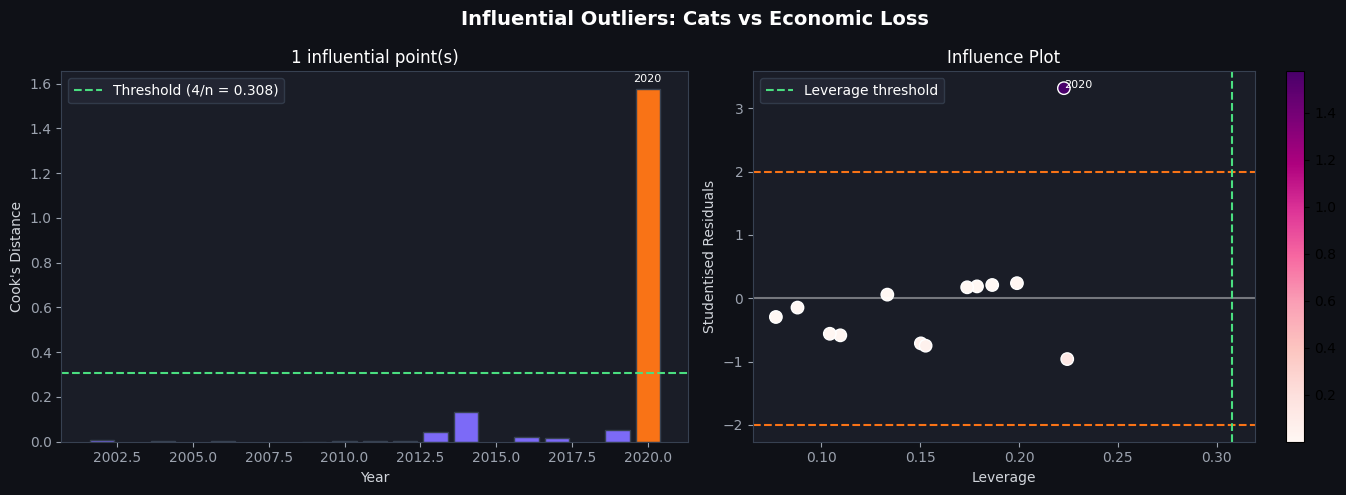


Cook's Distance threshold: 0.3077
Influential years: [np.int64(2020)]


In [103]:
## data
fce.columns = fce.columns.str.strip()

cols = ['year', 'cats_occurrence_total', 'eco_cost_total']
for col in cols:
    fce[col] = pd.to_numeric(fce[col], errors='coerce')

aus = fce[fce['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'eco_cost_total'])

X_raw = aus['cats_occurrence_total'].values
y = aus['eco_cost_total'].values
years = aus['year'].values
n = len(y)

## regression 
X_mat = np.column_stack([np.ones(n), X_raw])

beta = np.linalg.lstsq(X_mat, y, rcond=None)[0]
y_pred = X_mat @ beta
residuals = y - y_pred

## leverage
H = X_mat @ np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T
leverage = np.diag(H)

## standardized residuals
mse = np.sum(residuals ** 2) / (n - 2)
std_resid = residuals / np.sqrt(mse * (1 - leverage))

## COOK'S distance
k = 2
cooks_d = (std_resid ** 2 / k) * (leverage / (1 - leverage))

threshold = 4 / n

## style
DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle("Influential Outliers: Cats vs Economic Loss",
             fontsize=14, color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

## Cook's Distance
ax = axes[0]
colors = [A3 if d > threshold else A1 for d in cooks_d]

ax.bar(years, cooks_d, color=colors, edgecolor='#374151')
ax.axhline(threshold, color=A2, linestyle='--',
           label=f'Threshold (4/n = {threshold:.3f})')

for yr, d in zip(years, cooks_d):
    if d > threshold:
        ax.annotate(str(yr), (yr, d), xytext=(0, 5),
                    textcoords='offset points', ha='center', color='white', fontsize=8)

n_inf = sum(d > threshold for d in cooks_d)

ax.set_xlabel('Year')
ax.set_ylabel("Cook's Distance")
ax.set_title(f"{n_inf} influential point(s)")
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

## Leverage vs Residuals 
ax = axes[1]

sc = ax.scatter(leverage, std_resid, c=cooks_d, cmap='RdPu',
                s=80, edgecolors='white')

ax.axhline(0, color='white', alpha=0.4)
ax.axhline(2, color=A3, linestyle='--')
ax.axhline(-2, color=A3, linestyle='--')

lev_thresh = 2 * k / n
ax.axvline(lev_thresh, color=A2, linestyle='--',
           label=f'Leverage threshold')

for lev, res, yr in zip(leverage, std_resid, years):
    if abs(res) > 2 or lev > lev_thresh:
        ax.annotate(str(yr), (lev, res), fontsize=8, color='white')

cb = plt.colorbar(sc, ax=ax)
cb.ax.yaxis.label.set_color('white')

ax.set_xlabel('Leverage')
ax.set_ylabel('Studentised Residuals')
ax.set_title('Influence Plot')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.show()

print(f"\nCook's Distance threshold: {threshold:.4f}")
print("Influential years:",
      [years[i] for i, d in enumerate(cooks_d) if d > threshold])

Cook’s distance analysis identified the year 2020 as a highly influential observation. This suggests that the estimated relationship between cat occurrence and economic losses is disproportionately driven by a single extreme event. Removing this observation may significantly alter the model results, indicating that the relationship is not stable over time

## Let's delete an outlier

### Linear and polynomial regressions without an outlier:


In [104]:
## 1. remove 2020
aus_no_outlier = aus[aus['year'] != 2020].copy()

## 2. define X and y
X = aus_no_outlier[['cats_occurrence_total']]
y = aus_no_outlier['eco_cost_total']

##  3. linear model
lin_no = LinearRegression()
lin_no.fit(X, y)
r2_lin_no = lin_no.score(X, y)

##  4. polynomial model (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_no = poly.fit_transform(X)

pol_no = LinearRegression()
pol_no.fit(X_poly_no, y)
r2_pol_no = pol_no.score(X_poly_no, y)

## 5. print results
print(f"Linear R² without 2020: {r2_lin_no:.4f}")
print(f"Polynomial R² without 2020: {r2_pol_no:.4f}")

Linear R² without 2020: 0.0904
Polynomial R² without 2020: 0.1019


After removing the influential observation (2020), both linear and polynomial models exhibit similarly low explanatory power (R² ≈ 0.09–0.10). The polynomial model no longer provides a meaningful improvement, indicating that its earlier performance was driven by the outlier rather than a stable non-linear relationship.

 ## Lagged Relationship

In this section, we examine whether economic losses are related not only to current cat occurrence, but also to past values.


In [105]:
aus = fce[fce['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').reset_index(drop=True)

aus = aus[['year', 'cats_occurrence_total', 'eco_cost_total']].dropna()

lags = range(0, 6)
lag_corrs = []

for lag in lags:
    aus[f'cats_lag{lag}'] = aus['cats_occurrence_total'].shift(lag)
    tmp = aus.dropna(subset=[f'cats_lag{lag}', 'eco_cost_total'])
    
    if len(tmp) > 5:
        r, p = stats.pearsonr(tmp[f'cats_lag{lag}'], tmp['eco_cost_total'])
        lag_corrs.append({'lag': lag, 'r': r, 'p': p})

lag_df = pd.DataFrame(lag_corrs)

print(lag_df)

   lag         r         p
0    0  0.399313  0.176464
1    1  0.349713  0.265147
2    2  0.274002  0.414880
3    3  0.333222  0.346765
4    4  0.674033  0.046491
5    5  0.824937  0.011713


The results suggest that the relationship between cat occurrence and economic loss is weak in the short term, but becomes stronger at higher lags.


Scatter plot of lag to economic cost:

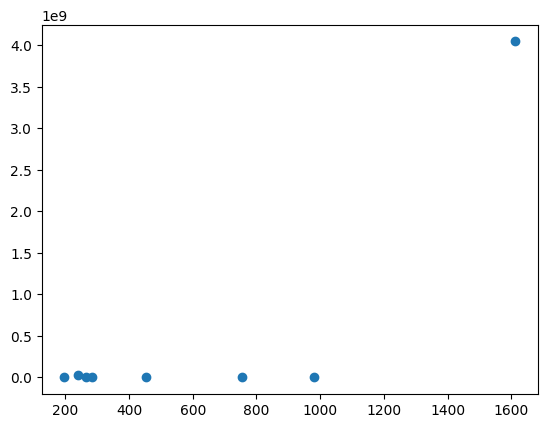

In [106]:
plt.scatter(tmp['cats_lag5'], tmp['eco_cost_total'])

Lagged correlation analysis suggests that the relationship between cat occurrence and economic losses is not immediate, but may materialize with a delay of approximately 4–5 years.

Although higher correlations are observed at longer lags, visual inspection reveals that these results are largely driven by a single extreme observation. Therefore, the apparent lagged relationship should be interpreted with caution and does not provide robust evidence of a systematic delayed effect."

To test whether the strong correlation at lag 5 is driven by extreme values, we remove outliers using the IQR method and recompute the correlation.

In [107]:
Q1 = tmp['eco_cost_total'].quantile(0.25)
Q3 = tmp['eco_cost_total'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

tmp_no_outlier = tmp[
    (tmp['eco_cost_total'] >= lower) &
    (tmp['eco_cost_total'] <= upper)
]

r_clean, p_clean = stats.pearsonr(
    tmp_no_outlier['cats_lag5'],
    tmp_no_outlier['eco_cost_total']
)

print(f"Cleaned correlation: r = {r_clean:.3f}, p = {p_clean:.4f}")

Cleaned correlation: r = -0.255, p = 0.6252


The results show that the correlation becomes weak and statistically insignificant (r ≈ -0.26, p > 0.6).

This indicates that the previously observed strong relationship was driven by a single extreme observation rather than a consistent pattern in the data.

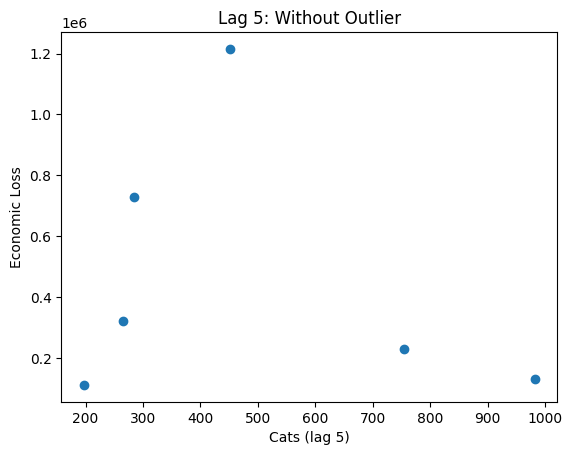

In [108]:
plt.scatter(
    tmp_no_outlier['cats_lag5'],
    tmp_no_outlier['eco_cost_total']
)
plt.title("Lag 5: Without Outlier")
plt.xlabel("Cats (lag 5)")
plt.ylabel("Economic Loss")
plt.show()

In [109]:
print("With outlier:", tmp_no_outlier)
print("Without outlier:", lag_df)

With outlier:     year  cats_occurrence_total  eco_cost_total  cats_lag0  cats_lag1  \
5   2011                  755.0    1.117943e+05      755.0      284.0   
6   2012                  982.0    3.213542e+05      982.0      755.0   
8   2014                 1870.0    1.215364e+06     1870.0     1612.0   
9   2016                 1406.0    7.289260e+05     1406.0     1870.0   
10  2017                 1371.0    2.301423e+05     1371.0     1406.0   
11  2019                 1622.0    1.302974e+05     1622.0     1371.0   

    cats_lag2  cats_lag3  cats_lag4  cats_lag5  
5       452.0      239.0      266.0      197.0  
6       284.0      452.0      239.0      266.0  
8       982.0      755.0      284.0      452.0  
9      1612.0      982.0      755.0      284.0  
10     1870.0     1612.0      982.0      755.0  
11     1406.0     1870.0     1612.0      982.0  
Without outlier:    lag         r         p
0    0  0.399313  0.176464
1    1  0.349713  0.265147
2    2  0.274002  0.414880
3    3

<Axes: xlabel='cats_occurrence_total', ylabel='eco_type_damage_loss'>

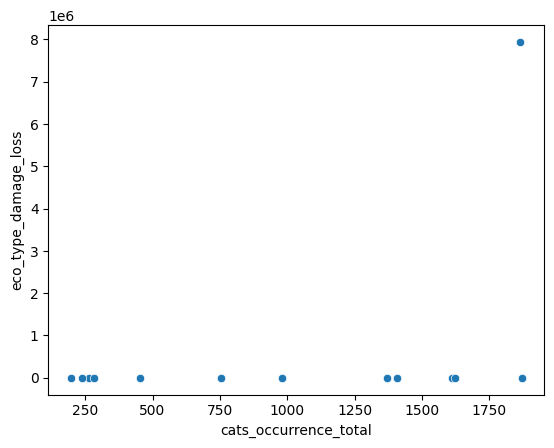

In [110]:
sns.scatterplot(
    x='cats_occurrence_total',
    y='eco_type_damage_loss',
    data=fce
)

In [111]:
tmp = fce[fce['territory'] == 'All Australia'][['year', 'cats_occurrence_total', 'eco_type_damage_loss']].copy()
tmp = tmp.sort_values('year')
tmp['cats_lag1'] = tmp['cats_occurrence_total'].shift(1)
tmp = tmp.dropna(subset=['cats_lag1', 'eco_type_damage_loss'])

r, p = stats.pearsonr(tmp['cats_lag1'], tmp['eco_type_damage_loss'])
print(f"r = {r:.3f}, p = {p:.4f}")

r = 0.350, p = 0.2653


## Correlation between damage costs and cat occurence

     year  cats_occurrence_total  eco_type_damage_loss
0    2002                  197.0          0.000000e+00
17   2004                  266.0          0.000000e+00
34   2006                  239.0          0.000000e+00
59   2009                  452.0          0.000000e+00
68   2010                  284.0          0.000000e+00
77   2011                  755.0          0.000000e+00
86   2012                  982.0          0.000000e+00
95   2013                 1612.0          0.000000e+00
104  2014                 1870.0          0.000000e+00
121  2016                 1406.0          0.000000e+00
130  2017                 1371.0          0.000000e+00
146  2019                 1622.0          0.000000e+00
154  2020                 1865.0          7.940169e+06
Pearson correlation: r = 0.3974, p = 0.1787
Linear coefficient: 1,328.9343
Intercept: -710,076.2033
R²: 0.1579


c:\Users\User\miniconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


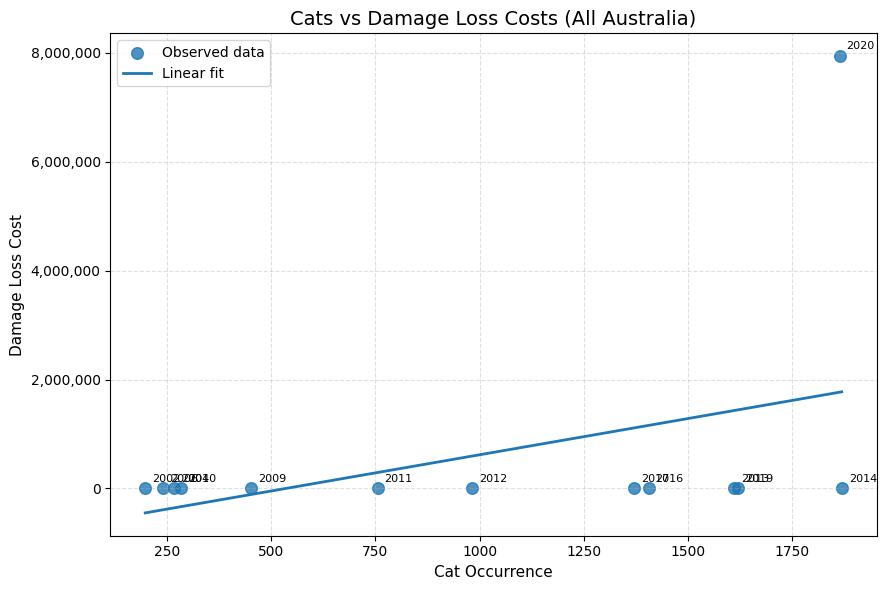

In [112]:
# -----------------------------
# 1. Prepare data
# -----------------------------
fce.columns = fce.columns.str.strip()

cols = ['year', 'cats_occurrence_total', 'eco_type_damage_loss']
for col in cols:
    fce[col] = pd.to_numeric(fce[col], errors='coerce')

aus_damage = fce[fce['territory'] == 'All Australia'].copy()
aus_damage = aus_damage.sort_values('year')
aus_damage = aus_damage[['year', 'cats_occurrence_total', 'eco_type_damage_loss']].dropna()

print(aus_damage)

# -----------------------------
# 2. Correlation
# -----------------------------
r, p = stats.pearsonr(
    aus_damage['cats_occurrence_total'],
    aus_damage['eco_type_damage_loss']
)

print(f"Pearson correlation: r = {r:.4f}, p = {p:.4f}")

# -----------------------------
# 3. Linear regression
# -----------------------------
X = aus_damage[['cats_occurrence_total']]
y = aus_damage['eco_type_damage_loss']

lin = LinearRegression()
lin.fit(X, y)

y_pred = lin.predict(X)
r2 = lin.score(X, y)

print(f"Linear coefficient: {lin.coef_[0]:,.4f}")
print(f"Intercept: {lin.intercept_:,.4f}")
print(f"R²: {r2:.4f}")

# -----------------------------
# 4. Scatter plot + regression line
# -----------------------------
x_grid = np.linspace(X.min().iloc[0], X.max().iloc[0], 200).reshape(-1, 1)
y_grid = lin.predict(x_grid)

plt.figure(figsize=(9, 6))

plt.scatter(
    aus_damage['cats_occurrence_total'],
    aus_damage['eco_type_damage_loss'],
    s=70,
    alpha=0.8,
    label='Observed data'
)

plt.plot(
    x_grid,
    y_grid,
    linewidth=2,
    label='Linear fit'
)

for _, row in aus_damage.iterrows():
    plt.annotate(
        str(int(row['year'])),
        (row['cats_occurrence_total'], row['eco_type_damage_loss']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.title("Cats vs Damage Loss Costs (All Australia)", fontsize=14)
plt.xlabel("Cat Occurrence", fontsize=11)
plt.ylabel("Damage Loss Cost", fontsize=11)

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

The scatter plot shows that most observations are clustered near zero damage cost, with no clear relationship between cat occurrence and economic loss.

However, one extreme observation (2020) exhibits a very high level of damage. This point drives the positive slope of the regression line.

This suggests that:
- the relationship is not consistent across years,
- damage costs are not gradually increasing with cat occurrence,
- but instead occur as rare, high-impact events.

Overall, there is no strong evidence of a stable relationship between cat occurrence and damage loss.